# 06 · Projeção de Atingimento do KPI

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autor(es):** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Data de criação:** 04/08/2026
**Última atualização:** 04/08/2026

## Objetivo

Projetar, a partir de qualquer ponto do ano, se as metas anuais de violação de OLA serão cumpridas.
Atende a exigência de visualização do atingimento de KPI e é o notebook em que os dois modelos das
etapas anteriores se combinam.

A construção parte de uma restrição que define todo o desenho: **o modelo de risco não pode pontuar
incidentes que ainda não existem**, porque ele depende de características que só passam a existir na
abertura. A solução é decompor o ano em três parcelas com níveis distintos de conhecimento, e aplicar
em cada uma a ferramenta adequada.

## Dependências

- Python 3.11+
- pandas, numpy, matplotlib
- prophet, scikit-learn, holidays

## Entradas

- `data/interim/incidentes_kpi.parquet` (gerado pelo `02_base_kpi.ipynb`)
- metas anuais do dicionário de dados oficial

## Saídas

- Gráficos exportados para `notebooks/figures/06_projecao_kpi/`
- Tabela de projeção em `data/interim/06_projecao.parquet`, para consumo pela aplicação
- Resultados documentados em `docs/sprint-3-mvp.md`

## Sumário

| Seção | Conteúdo |
|---|---|
| 3 | metas oficiais e o desenho da validação retrospectiva |
| 4.1 | a decomposição em três parcelas |
| 4.2 | parcela 1, o realizado |
| 4.3 | parcela 2, a fila em aberto pontuada pelo modelo de risco |
| 4.4 | parcela 3, o volume futuro e a escolha de configuração do Prophet |
| 4.5 | a projeção completa |
| 4.6 | validação contra o ano fechado, em cinco pontos de projeção |
| 4.7 | de onde vem o erro |
| 4.8 | saída para a aplicação |
| 5 | conclusões e limitações |

In [1]:
# Stdlib
import glob
import logging
import os
import warnings
from pathlib import Path

# Third-party
import holidays
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

# Windows: o cmdstan usado pelo Prophet precisa da pasta 'tbb' no PATH antes do primeiro import
_tbb = [d for d in glob.glob(str(RAIZ / '.venv' / 'Lib' / 'site-packages' / 'prophet'
                                / 'stan_model' / '**' / 'tbb'), recursive=True) if os.path.isdir(d)]
if _tbb:
    os.environ['PATH'] = os.path.abspath(_tbb[0]) + os.pathsep + os.environ['PATH']
from prophet import Prophet

# Silencia os logs de ajuste do cmdstan
for _lg in ('prophet', 'cmdstanpy'):
    logging.getLogger(_lg).setLevel(logging.ERROR)
    logging.getLogger(_lg).propagate = False
logging.getLogger('cmdstanpy').disabled = True

## 1. Setup

Paleta e estilo dos gráficos (padrão visual do projeto), caminhos e funções auxiliares.

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706', 'verde': '#15A05B'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'

FIG_DIR = RAIZ / 'notebooks' / 'figures' / '06_projecao_kpi'
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEMENTE = 42

def fmt(x, casas=2):
    """Formata número no padrão PT-BR (vírgula decimal)."""
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    """Formata inteiro no padrão PT-BR (ponto de milhar)."""
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

## 2. Carga dos dados

In [3]:
df_kpi = pd.read_parquet(PARQUET)
df_kpi['violou'] = (df_kpi['KPI Violado?'] == 'SIM').astype(int)
df_kpi['pri'] = df_kpi['Prioridade'].astype(str).str[0].map({'2': 'P2', '3': 'P3'})
feriados_br = holidays.Brazil(years=sorted(df_kpi['ano'].unique().tolist()))
df_kpi['is_feriado'] = df_kpi['dia'].dt.date.map(lambda d: int(d in feriados_br))

FIM_ANO = pd.Timestamp('2025-12-31')
df_ano = df_kpi[df_kpi['ano'] == 2025].copy()

assert len(df_kpi) == 25_600
print(f'Base: {fmt_int(len(df_kpi))} incidentes elegíveis ao KPI')
print(f'Recorte de 2025: {fmt_int(len(df_ano))} incidentes, '
      f'{int(df_ano["violou"].sum())} violações de OLA')

Base: 25.600 incidentes elegíveis ao KPI
Recorte de 2025: 25.156 incidentes, 238 violações de OLA


## 3. As metas e o desenho da validação

O dicionário de dados define metas anuais de violação de OLA por prioridade. São elas que a projeção
tem que responder.

**Desenho da validação.** A base termina em 31/12/2025 e as metas são de 2025, portanto o ano está
fechado e o resultado é conhecido. Isso permite uma validação retrospectiva: escolhe-se uma data como
"presente", projeta-se o fechamento usando apenas informação disponível até ali, e compara-se com o
resultado real.

O procedimento é repetido em cinco datas, de agosto a dezembro, para medir como a projeção se comporta
conforme sobra menos ano a estimar. Trata-se de validação retrospectiva e não de previsão real, o que
está declarado entre as limitações.

In [4]:
# meta de violações de OLA por prioridade: (mínimo, máximo)
META = {'P2': (40, 45), 'P3': (0, 200)}

fechado = df_ano.groupby('pri').agg(incidentes=('violou', 'size'), violacoes=('violou', 'sum'))
for p in ['P2', 'P3']:
    lo, hi = META[p]
    faixa = f'{lo} a {hi}' if lo else f'até {hi}'
    print(f'{p}: meta de {faixa} violações | fechou o ano com '
          f'{int(fechado.loc[p, "violacoes"])} em {fmt_int(fechado.loc[p, "incidentes"])} incidentes')

P2: meta de 40 a 45 violações | fechou o ano com 42 em 5.159 incidentes
P3: meta de até 200 violações | fechou o ano com 196 em 19.997 incidentes


## 4. Construção da projeção

### 4.1 A decomposição em três parcelas

O modelo de risco atribui probabilidade a um incidente a partir de suas características: equipe,
produto, categoria, item de configuração, horário. Um incidente que ainda não foi aberto não possui
nenhuma delas, de modo que **não é pontuável**. Essa restrição, e não uma escolha de conveniência,
determina o desenho.

O ano é separado em três parcelas conforme o que se sabe em cada uma na data de projeção:

| Parcela | Definição | Conhecimento disponível | Ferramenta |
|---|---|---|---|
| **1** | aberto antes do corte **e** resolvido antes do corte | desfecho registrado | contagem |
| **2** | aberto antes do corte **e** não resolvido | características, sem desfecho | modelo de risco |
| **3** | aberto a partir do corte | nada | Prophet e taxa esperada |

A definição da parcela 1 exige **duas** condições. Restringi-la a "aberto antes do corte" incluiria os
incidentes ainda em andamento, que compõem a parcela 2, e produziria dupla contagem. A verificação
adiante confirma que as três parcelas somam exatamente o ano.

In [5]:
def separa_parcelas(dados, corte):
    """Divide os incidentes em três parcelas mutuamente exclusivas."""
    abriu_antes = dados['dia'] < corte
    resolveu_antes = (dados['Resolvido'] < corte).fillna(False)
    return np.where(~abriu_antes, 'parcela 3 · abre depois do corte',
           np.where(resolveu_antes, 'parcela 1 · resolvido antes do corte',
                    'parcela 2 · em aberto no corte'))

CORTE_BASE = pd.Timestamp('2025-10-01')
df_ano['parcela'] = separa_parcelas(df_ano, CORTE_BASE)

visao = (df_ano.groupby(['parcela', 'pri'])
         .agg(incidentes=('violou', 'size'), violacoes=('violou', 'sum')).unstack())
print(f'data de projeção simulada: {CORTE_BASE:%d/%m/%Y}')
print()
print(visao.to_string())
print()

soma = df_ano.groupby('parcela')['violou'].agg(['size', 'sum'])
assert soma['size'].sum() == len(df_ano), 'as parcelas não somam o total de incidentes'
assert soma['sum'].sum() == df_ano['violou'].sum(), 'as parcelas não somam o total de violações'
print(f'verificação: {fmt_int(soma["size"].sum())} incidentes e {int(soma["sum"].sum())} violações '
      f'nas três parcelas, contra {fmt_int(len(df_ano))} e {int(df_ano["violou"].sum())} no ano')

data de projeção simulada: 01/10/2025

                                     incidentes        violacoes     
pri                                          P2     P3        P2   P3
parcela                                                              
parcela 1 · resolvido antes do corte       3884  14960        33  145
parcela 2 · em aberto no corte               27   1102         0   10
parcela 3 · abre depois do corte           1248   3935         9   41

verificação: 25.156 incidentes e 238 violações nas três parcelas, contra 25.156 e 238 no ano


**Achado:** as parcelas fecham exatamente, sem sobreposição nem omissão.

A distribuição entre elas antecipa o comportamento da projeção. Na data simulada, a parcela 1 reúne
3.884 dos 5.159 incidentes de P2 e 14.960 dos 19.997 de P3. **A maior parte da projeção é contagem de
fatos, não estimativa**, e é isso que a torna precisa mesmo quando as parcelas estimadas erram.

A parcela 2 do P2 tem apenas 27 incidentes. É consequência do tempo de resolução: a mediana do P2 é de
26 minutos, então praticamente não há fila acumulada em nenhum instante.

### 4.2 Parcela 1 · o realizado

Incidentes abertos e resolvidos antes da data de projeção têm o campo `KPI Violado?` preenchido. Não
há estimativa envolvida.

In [6]:
def parcela1(dados, corte, pri):
    """Violações já registradas: contagem, sem modelo."""
    s = dados[(dados['pri'] == pri) & (dados['dia'] < corte) & (dados['Resolvido'] < corte)]
    return int(s['violou'].sum()), len(s)

for p in ['P2', 'P3']:
    v, n = parcela1(df_ano, CORTE_BASE, p)
    print(f'{p}: {v} violações registradas em {fmt_int(n)} incidentes resolvidos '
          f'(taxa de {fmt(v/n*100)}%)')

P2: 33 violações registradas em 3.884 incidentes resolvidos (taxa de 0,85%)
P3: 145 violações registradas em 14.960 incidentes resolvidos (taxa de 0,97%)


### 4.3 Parcela 2 · a fila em aberto

Estes incidentes existem e suas características são conhecidas, mas o desfecho não. É a situação para
a qual o modelo de risco do `04_risco_ola.ipynb` foi construído.

**Restrição de treino.** O modelo é treinado apenas com incidentes **resolvidos antes da data de
projeção**. Incluir os que estão em aberto usaria o desfecho deles para estimar o próprio desfecho.
O `04_risco_ola.ipynb` treina com o corte por data de abertura; a diferença foi medida e é
imaterial, mas aqui a restrição mais estrita é adotada por coerência com a simulação.

**Sobre somar probabilidades.** O total esperado de violações de um grupo é a soma das probabilidades
individuais, e o resultado é fracionário. Dez eventos com 10% de probabilidade cada produzem uma
expectativa de um evento, não um evento identificado. Um total de 0,1 significa que praticamente
nenhuma violação é esperada daquele grupo.

In [7]:
CATEGORICAS = ['Prioridade', 'Grupo designado', 'Aberto por', 'Produto',
               'Categoria', 'Subcategoria', 'Item de configuração']
NUMERICAS = ['hora', 'dia_semana', 'is_feriado']
CARACTERISTICAS = CATEGORICAS + NUMERICAS

def novo_modelo_risco():
    pre = ColumnTransformer([
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='(vazio)')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=100))]), CATEGORICAS),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), NUMERICAS)])
    return Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=5000, random_state=SEMENTE))])

def matriz_x(dados):
    x = dados[CARACTERISTICAS].copy()
    x[CATEGORICAS] = x[CATEGORICAS].astype(str)
    return x

def treina_risco_ate(corte):
    """Treina o modelo de risco apenas com o que estava resolvido na data de projeção."""
    tr = df_kpi[(df_kpi['dia'] < corte) & (df_kpi['Resolvido'] < corte)]
    m = novo_modelo_risco()
    m.fit(matriz_x(tr), tr['violou'])
    return m, tr

def parcela2(dados, corte, pri, modelo):
    """Violações esperadas da fila em aberto: soma das probabilidades individuais."""
    s = dados[(dados['pri'] == pri) & (dados['dia'] < corte)
              & ~(dados['Resolvido'] < corte).fillna(False)]
    if not len(s):
        return 0.0, 0, 0
    return float(modelo.predict_proba(matriz_x(s))[:, 1].sum()), len(s), int(s['violou'].sum())

modelo_risco, treino_risco = treina_risco_ate(CORTE_BASE)
print(f'modelo de risco treinado com {fmt_int(len(treino_risco))} incidentes resolvidos até '
      f'{CORTE_BASE:%d/%m/%Y} ({int(treino_risco["violou"].sum())} violações conhecidas)')
print()
for p in ['P2', 'P3']:
    esperado, n, ocorrido = parcela2(df_ano, CORTE_BASE, p, modelo_risco)
    print(f'{p}: {n:5d} incidentes em aberto | esperado {fmt(esperado, 1)} | ocorrido {ocorrido}')

modelo de risco treinado com 19.199 incidentes resolvidos até 01/10/2025 (187 violações conhecidas)

P2:    27 incidentes em aberto | esperado 0,1 | ocorrido 0
P3:  1102 incidentes em aberto | esperado 5,3 | ocorrido 10


**Achado:** no P2 o modelo esperava 0,1 violação dos 27 incidentes em aberto e não houve nenhuma.
No P3 esperava 5,3 e ocorreram 10, subestimação que corresponde a cinco casos numa fila de 1.102 e
carrega a incerteza própria de um evento com taxa inferior a 1%.

Em termos de contribuição à projeção, a parcela 2 é a menor das três.

### 4.4 Parcela 3 · o volume futuro

Incidentes que ainda não foram abertos não têm características, portanto o modelo de risco não se
aplica. A estimativa é feita em duas etapas: o Prophet projeta **quantos** incidentes chegam, e a taxa
esperada de violação, extraída do próprio modelo de risco aplicado ao período de treino, converte
volume em violações.

#### 4.4.1 A configuração do Prophet depende do horizonte

O `03_previsao_volume.ipynb` valida o Prophet para o horizonte de D+1 a D+7 e utiliza tendência linear.
Aqui o horizonte vai de 31 a 153 dias, e a tendência passa a ter efeito distinto: uma inclinação
estimada sobre série praticamente estável é extrapolada por meses, convertendo oscilação em erro
sistemático.

O `03_previsao_volume.ipynb` concluiu que o sinal previsível da série é o calendário, isto é, dia útil
contra fim de semana e feriado. A configuração `growth='flat'` é a tradução dessa conclusão: mantém o
patamar e aplica apenas a sazonalidade semanal, sem estimar inclinação.

A comparação abaixo mede as duas configurações nos dois horizontes.

In [8]:
def serie_diaria(pri):
    s = (df_ano[df_ano['pri'] == pri].groupby('dia').size()
         .rename('y').reset_index().rename(columns={'dia': 'ds'}))
    calendario = pd.DataFrame({'ds': pd.date_range(pd.Timestamp('2025-01-01'), FIM_ANO)})
    return calendario.merge(s, on='ds', how='left').fillna({'y': 0})

SERIES = {p: serie_diaria(p) for p in ['P2', 'P3']}

def ajusta_prophet(treino, growth):
    m = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False,
                interval_width=0.80, growth=growth)
    m.add_country_holidays(country_name='BR')
    m.fit(treino)
    return m

def preve_volume(pri, corte, growth='linear'):
    """Volume previsto do corte até o fim do ano, com a faixa de 80%."""
    s = SERIES[pri]
    fc = ajusta_prophet(s[s['ds'] < corte], growth).predict(s[['ds']])
    for c in ['yhat', 'yhat_lower', 'yhat_upper']:
        fc[c] = fc[c].clip(lower=0)
    fut = fc[fc['ds'] >= corte]
    return {'previsto': fut['yhat'].sum(), 'baixo': fut['yhat_lower'].sum(),
            'alto': fut['yhat_upper'].sum(),
            'real': float(s[s['ds'] >= corte]['y'].sum()), 'dias': len(fut)}

CORTES = [pd.Timestamp(d) for d in ['2025-08-01', '2025-09-01', '2025-10-01',
                                    '2025-11-01', '2025-12-01']]
longo = []
for C in CORTES:
    for p in ['P2', 'P3']:
        s = SERIES[p]
        realizado, ano = s[s['ds'] < C]['y'].sum(), s['y'].sum()
        linha = {'projetado em': C.strftime('%d/%m'), 'prioridade': p}
        for g in ['linear', 'flat']:
            prev = preve_volume(p, C, g)['previsto']
            linha[f'erro {g} %'] = round(((realizado + prev) - ano) / ano * 100, 1)
        longo.append(linha)
tab_longo = pd.DataFrame(longo)
print('horizonte longo · erro na projeção do volume anual:')
print(tab_longo.to_string(index=False))
print()
print('erro absoluto médio:')
print(tab_longo.groupby('prioridade')[['erro linear %', 'erro flat %']]
      .apply(lambda d: d.abs().mean()).round(2).to_string())

horizonte longo · erro na projeção do volume anual:
projetado em prioridade  erro linear %  erro flat %
       01/08         P2          -14.7          2.3
       01/08         P3            3.1          6.0
       01/09         P2           -7.5          1.5
       01/09         P3            7.9          7.3
       01/10         P2           -0.7          1.6
       01/10         P3            8.9          7.8
       01/11         P2            0.3          1.2
       01/11         P3            6.4          6.6
       01/12         P2            1.5          1.7
       01/12         P3            1.8          3.8

erro absoluto médio:
            erro linear %  erro flat %
prioridade                            
P2                   4.94         1.66
P3                   5.62         6.30


In [9]:
# horizonte curto: o mesmo tipo de teste feito no notebook 03
ORIGENS = pd.date_range('2025-07-01', '2025-12-17', freq='14D')
curto = []
for p in ['P2', 'P3']:
    s = SERIES[p]
    for g in ['linear', 'flat']:
        erros = []
        for origem in ORIGENS:
            tr = s[s['ds'] <= origem]
            if len(tr) < 60:
                continue
            fut = pd.DataFrame({'ds': pd.date_range(origem + pd.Timedelta(days=1), periods=7)})
            fc = ajusta_prophet(tr, g).predict(fut)
            fc['yhat'] = fc['yhat'].clip(lower=0)
            j = fc[['ds', 'yhat']].merge(s[['ds', 'y']], on='ds')
            erros.append(np.abs(j['yhat'] - j['y']).mean())
        curto.append({'prioridade': p, 'config': g, 'MAE D+1 a D+7': round(np.mean(erros), 2)})
print(f'horizonte curto · rolling backtest com {len(ORIGENS)} origens e 7 dias de horizonte:')
print(pd.DataFrame(curto).pivot_table(index='prioridade', columns='config',
                                      values='MAE D+1 a D+7')[['linear', 'flat']].to_string())

horizonte curto · rolling backtest com 13 origens e 7 dias de horizonte:
config      linear   flat
prioridade               
P2            3.80   3.98
P3           10.89  12.07


**Achado, e ele contraria a decisão que parecia óbvia.**

Medido pelo erro de volume, a configuração sem tendência é superior no horizonte longo: o erro absoluto
médio do P2 cai de 4,94% para 1,66%. No horizonte curto o resultado inverte, com vantagem da tendência
linear. A leitura imediata seria adotar `growth='flat'` neste notebook.

Ela não se sustenta quando a avaliação passa para o objetivo real. Repetindo as dez projeções da seção
4.6 com as duas configurações:

| Configuração | Situação da meta correta | Faixa contendo o real |
|---|---|---|
| `linear` | **7 de 10** | **10 de 10** |
| `flat` | 4 de 10 | 7 de 10 |

A configuração com melhor previsão de volume produz a **pior** projeção de KPI. O mecanismo é a largura
da faixa: sem tendência a estimar, o Prophet não tem incerteza de tendência, a faixa estreita, e passa
a excluir o valor real com mais frequência. Uma previsão central mais próxima com faixa estreita demais
conduz a mais conclusões erradas sobre a meta do que uma previsão central pior com faixa honesta.

**Decisão: tendência linear nos dois notebooks.** O erro de volume é métrica intermediária; o critério
de escolha é o acerto da situação em relação à meta e a cobertura da faixa, que são o que a aplicação
entrega.

Fica registrado como resultado metodológico: otimizar a etapa intermediária degradou o resultado final,
e a comparação só apareceu porque as duas configurações foram avaliadas até o fim da cadeia.

Ressalva: o backtest de horizonte curto acima não reproduz o protocolo do `03_previsao_volume.ipynb`,
que usa outro espaçamento de origens. Os valores absolutos não são comparáveis aos dele; a comparação
entre as duas configurações é válida porque ambas usaram o mesmo protocolo.

### 4.5 A projeção completa

In [10]:
def taxa_esperada(modelo, treino, pri):
    """Taxa de violação esperada, obtida do modelo de risco no período de treino."""
    return float(modelo.predict_proba(matriz_x(treino[treino['pri'] == pri]))[:, 1].mean())

def projeta(corte, pri, modelo, treino):
    p1, n1 = parcela1(df_ano, corte, pri)
    p2, n2, _ = parcela2(df_ano, corte, pri, modelo)
    v = preve_volume(pri, corte, 'linear')
    taxa = taxa_esperada(modelo, treino, pri)
    p3, p3lo, p3hi = v['previsto'] * taxa, v['baixo'] * taxa, v['alto'] * taxa
    return {'corte': corte, 'prioridade': pri, 'parcela 1': p1, 'parcela 2': p2, 'parcela 3': p3,
            'projeção': p1 + p2 + p3, 'faixa baixa': p1 + p2 + p3lo, 'faixa alta': p1 + p2 + p3hi,
            'real': int(df_ano[df_ano['pri'] == pri]['violou'].sum()),
            'n1': n1, 'n2': n2, 'volume previsto': v['previsto'], 'taxa': taxa}

def situacao(valor, pri):
    lo, hi = META[pri]
    return 'acima da meta' if valor > hi else ('abaixo da faixa' if valor < lo else 'dentro da meta')

base = [projeta(CORTE_BASE, p, modelo_risco, treino_risco) for p in ['P2', 'P3']]
for r in base:
    lo, hi = META[r['prioridade']]
    print(f"--- {r['prioridade']}   meta: {f'{lo} a {hi}' if lo else f'até {hi}'} violações")
    print(f"  parcela 1 · resolvido    {r['parcela 1']:8.1f}   {fmt_int(r['n1'])} incidentes, contagem")
    print(f"  parcela 2 · em aberto    {r['parcela 2']:8.1f}   {r['n2']} incidentes, modelo de risco")
    print(f"  parcela 3 · vai chegar   {r['parcela 3']:8.1f}   {r['volume previsto']:.0f} previstos "
          f"× {fmt(r['taxa']*100)}%")
    print(f"  {'-'*68}")
    print(f"  projeção do ano          {r['projeção']:8.1f}   faixa "
          f"{r['faixa baixa']:.0f} a {r['faixa alta']:.0f}")
    print(f"  real                     {r['real']:8d}   erro "
          f"{(r['projeção']-r['real'])/r['real']*100:+.1f}%")
    print(f"  situação projetada: {situacao(r['projeção'], r['prioridade'])} | "
          f"situação real: {situacao(r['real'], r['prioridade'])}")
    print()

--- P2   meta: 40 a 45 violações
  parcela 1 · resolvido        33.0   3.884 incidentes, contagem
  parcela 2 · em aberto         0.1   27 incidentes, modelo de risco
  parcela 3 · vai chegar       10.4   1210 previstos × 0,86%
  --------------------------------------------------------------------
  projeção do ano              43.5   faixa 38 a 49
  real                           42   erro +3.5%
  situação projetada: dentro da meta | situação real: dentro da meta

--- P3   meta: até 200 violações
  parcela 1 · resolvido       145.0   14.960 incidentes, contagem
  parcela 2 · em aberto         5.3   1102 incidentes, modelo de risco
  parcela 3 · vai chegar       57.7   5717 previstos × 1,01%
  --------------------------------------------------------------------
  projeção do ano             208.0   faixa 191 a 225
  real                          196   erro +6.1%
  situação projetada: acima da meta | situação real: dentro da meta



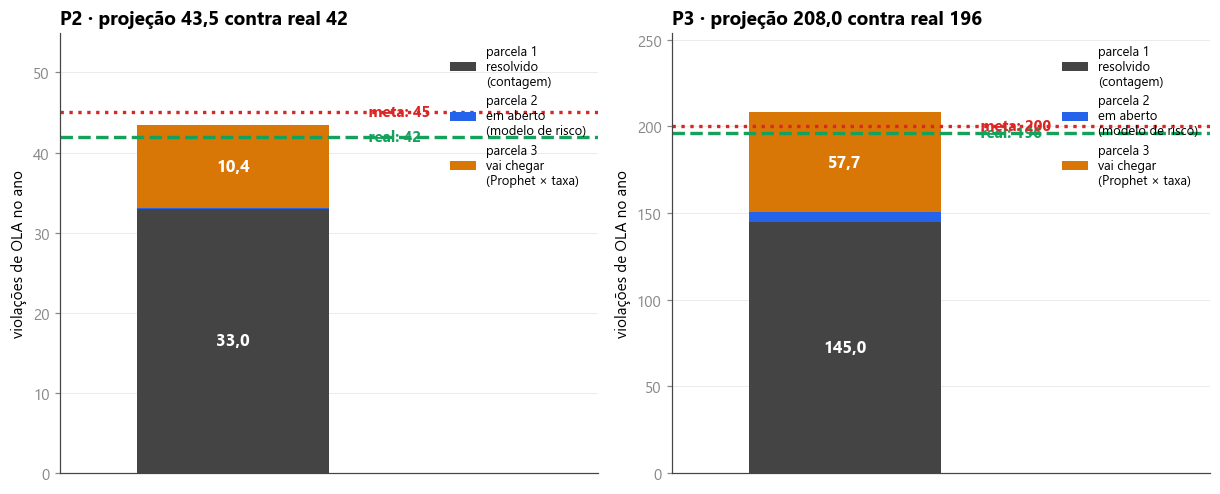

In [11]:
# figura 01: a composição da projeção
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
for ax, r in zip(axes, base):
    valores = [r['parcela 1'], r['parcela 2'], r['parcela 3']]
    nomes = ['parcela 1\nresolvido\n(contagem)', 'parcela 2\nem aberto\n(modelo de risco)',
             'parcela 3\nvai chegar\n(Prophet × taxa)']
    cores = [COR['cinza_esc'], COR['accent'], COR['ambar']]
    base_y = 0
    for v, c, nome in zip(valores, cores, nomes):
        ax.bar([0], [v], bottom=[base_y], color=c, width=0.5, label=nome)
        if v > r['projeção'] * 0.03:
            ax.text(0, base_y + v / 2, fmt(v, 1), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)
        base_y += v
    lo, hi = META[r['prioridade']]
    ax.axhline(r['real'], color=COR['verde'], lw=2.2, ls='--')
    ax.text(0.33, r['real'], f"  real: {r['real']}", color=COR['verde'],
            fontweight='bold', fontsize=10, va='center')
    ax.axhline(hi, color=COR['danger'], lw=2.2, ls=':')
    ax.text(0.33, hi, f'  meta: {hi}', color=COR['danger'], fontweight='bold',
            fontsize=10, va='center')
    ax.set_xlim(-0.45, 0.95); ax.set_xticks([])
    ax.set_ylim(0, max(r['projeção'], hi) * 1.22)
    ax.set_ylabel('violações de OLA no ano')
    ax.set_title(f"{r['prioridade']} · projeção {fmt(r['projeção'], 1)} contra real {r['real']}",
                 loc='left')
    ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout(); salvar_fig(fig, '01_composicao_projecao'); plt.show()

**Achado:** a parcela de contagem responde por 76% da projeção do P2 e 70% da do P3 na data
simulada. A precisão da projeção decorre dessa composição: as parcelas estimadas atuam sobre a fração
minoritária do total.

### 4.6 Validação em cinco pontos de projeção

A projeção é repetida em cinco datas. O que se avalia é o erro do valor projetado e, principalmente,
se a situação projetada em relação à meta coincide com a real.

In [12]:
todos = []
for C in CORTES:
    m, tr = treina_risco_ate(C)
    for p in ['P2', 'P3']:
        r = projeta(C, p, m, tr)
        r['erro %'] = round((r['projeção'] - r['real']) / r['real'] * 100, 1)
        r['situação projetada'] = situacao(r['projeção'], p)
        r['situação real'] = situacao(r['real'], p)
        r['acertou'] = r['situação projetada'] == r['situação real']
        r['faixa contém o real'] = bool(r['faixa baixa'] <= r['real'] <= r['faixa alta'])
        todos.append(r)

tab = pd.DataFrame(todos)
tab['projetado em'] = tab['corte'].dt.strftime('%d/%m')
colunas = ['projetado em', 'parcela 1', 'parcela 2', 'parcela 3', 'projeção',
           'faixa baixa', 'faixa alta', 'real', 'erro %', 'acertou', 'faixa contém o real']
for p in ['P2', 'P3']:
    print(f'--- {p}')
    print(tab[tab['prioridade'] == p][colunas].round(1).to_string(index=False))
    print()
print(f"situação correta em {int(tab['acertou'].sum())} de {len(tab)} projeções")
print(f"faixa contendo o real em {int(tab['faixa contém o real'].sum())} de {len(tab)}")
print(f"erro absoluto máximo: {tab['erro %'].abs().max():.1f}%")

--- P2
projetado em  parcela 1  parcela 2  parcela 3  projeção  faixa baixa  faixa alta  real  erro %  acertou  faixa contém o real
       01/08         28        0.1       12.3      40.4         32.4        49.1    42    -3.8     True                 True
       01/09         31        0.1       11.7      42.8         36.1        49.6    42     2.0     True                 True
       01/10         33        0.1       10.4      43.5         38.3        48.7    42     3.5     True                 True
       01/11         35        0.1        6.8      41.9         38.7        45.2    42    -0.2     True                 True
       01/12         41        0.1        3.8      44.9         43.2        46.6    42     6.9     True                False

--- P3
projetado em  parcela 1  parcela 2  parcela 3  projeção  faixa baixa  faixa alta  real  erro %  acertou  faixa contém o real
       01/08        120        5.9       90.9     216.7        186.0       248.3   196    10.6    False       

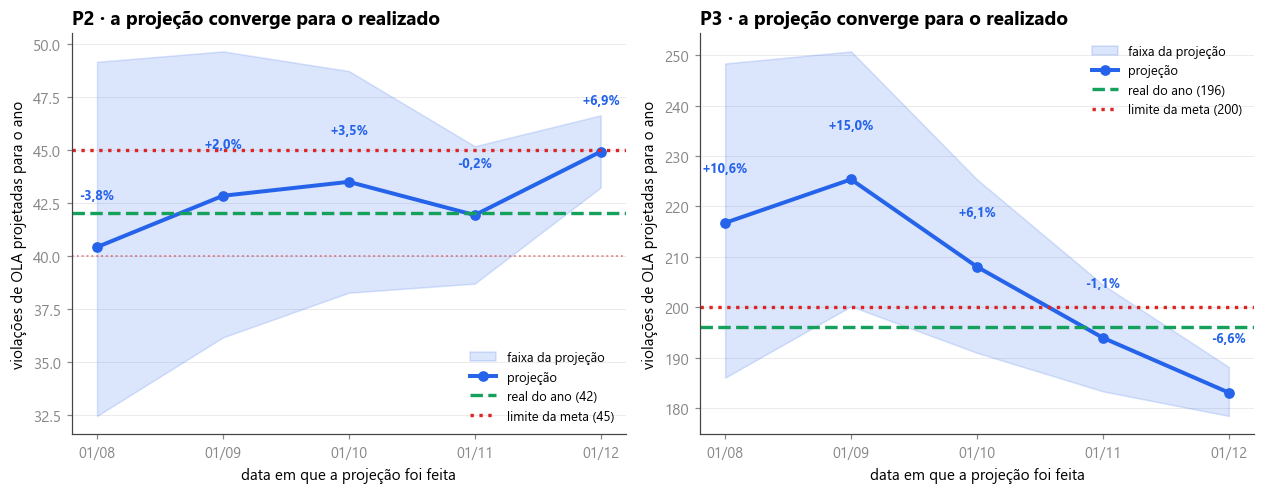

In [13]:
# figura 02: a projeção contra a meta ao longo do ano
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
for ax, p in zip(axes, ['P2', 'P3']):
    s = tab[tab['prioridade'] == p].sort_values('corte')
    x = np.arange(len(s))
    lo, hi = META[p]
    ax.fill_between(x, s['faixa baixa'], s['faixa alta'], color=COR['accent'], alpha=0.16,
                    label='faixa da projeção')
    ax.plot(x, s['projeção'], color=COR['accent'], lw=2.6, marker='o', ms=6, label='projeção')
    ax.axhline(s['real'].iloc[0], color=COR['verde'], lw=2.2, ls='--',
               label=f"real do ano ({int(s['real'].iloc[0])})")
    ax.axhline(hi, color=COR['danger'], lw=2.2, ls=':', label=f'limite da meta ({hi})')
    if lo:
        ax.axhline(lo, color=COR['danger'], lw=1.2, ls=':', alpha=0.55)
    for i, (v, e) in enumerate(zip(s['projeção'], s['erro %'])):
        ax.annotate(f'{e:+.1f}%'.replace('.', ','), xy=(i, v), xytext=(i, v + hi * 0.05),
                    ha='center', fontsize=8.5, fontweight='bold', color=COR['accent'])
    ax.set_xticks(x); ax.set_xticklabels(s['projetado em'], fontsize=9.5)
    ax.set_xlabel('data em que a projeção foi feita')
    ax.set_ylabel('violações de OLA projetadas para o ano')
    ax.set_title(f'{p} · a projeção converge para o realizado', loc='left')
    ax.legend(loc='best', fontsize=8.5)
plt.tight_layout(); salvar_fig(fig, '02_projecao_vs_meta'); plt.show()

**Achado, em três partes.**

**O P2 acerta a situação nas cinco datas**, com erro absoluto de até 3,8%. A projeção fica estável em
torno do valor real desde agosto.

**O P3 acerta a partir de novembro e erra nas três datas anteriores.** Os três erros têm o mesmo
sentido e magnitude decrescente: 216,7 em agosto, 225,3 em setembro e 208,0 em outubro, contra o limite
de 200 e o realizado de 196. Não são erros independentes, e sim a mesma superestimação convergindo.

A causa é conhecida e está documentada no `03_previsao_volume.ipynb`: novembro e dezembro registraram
queda real de volume no P3. Uma projeção construída com informação até outubro não dispõe de nenhum
sinal dessa queda, e nenhuma configuração de modelo altera isso, porque a limitação é de informação e
não de método.

**A faixa conteve o valor real em 7 das 10 projeções**, e em 2 das 3 em que o valor central cruzou o
limite da meta. É desempenho superior ao do valor central isolado, mas não é cobertura completa: nas
projeções de dezembro a faixa estreita o suficiente para excluir o realizado em ambas as prioridades, e
em setembro o limite inferior do P3 ficou acima do valor observado.

O argumento para apresentar faixa em vez de valor único permanece, porque em 2 dos 3 casos de conclusão
errada sobre a meta a faixa ainda continha a resposta correta. Mas a faixa não deve ser apresentada como
intervalo de confiança calibrado, e sim como indicação da ordem de incerteza.

Os três erros ocorrem no sentido conservador, projetando mais violações do que as observadas. Em
nenhuma das dez projeções ocorreu o erro oposto, de projetar cumprimento de meta que não se
confirmaria.

### 4.7 De onde vem o erro

O erro da projeção pode originar-se do volume previsto ou da taxa de violação assumida. A separação
indica onde há margem de melhoria.

In [14]:
diag = []
for r in todos:
    C, p = r['corte'], r['prioridade']
    v = preve_volume(p, C, 'linear')
    futuro = df_ano[(df_ano['pri'] == p) & (df_ano['dia'] >= C)]
    diag.append({'projetado em': C.strftime('%d/%m'), 'prioridade': p,
                 'volume previsto': round(v['previsto']), 'volume real': int(v['real']),
                 'erro do volume %': round((v['previsto'] - v['real']) / v['real'] * 100, 1),
                 'taxa usada %': round(r['taxa'] * 100, 2),
                 'taxa observada %': round(futuro['violou'].mean() * 100, 2),
                 'erro da projeção %': r['erro %']})
d = pd.DataFrame(diag)
for p in ['P2', 'P3']:
    print(f'--- {p}')
    print(d[d['prioridade'] == p].drop(columns='prioridade').to_string(index=False))
    print()
print('correlação entre erro do volume e erro da projeção: '
      f"{d['erro do volume %'].corr(d['erro da projeção %']):.2f}")

--- P2
projetado em  volume previsto  volume real  erro do volume %  taxa usada %  taxa observada %  erro da projeção %
       01/08             1348         2104             -35.9          0.91              0.67                -3.8
       01/09             1301         1690             -23.0          0.90              0.65                 2.0
       01/10             1210         1248              -3.0          0.86              0.72                 3.5
       01/11              830          812               2.2          0.82              0.86                -0.2
       01/12              440          364              20.9          0.86              0.27                 6.9

--- P3
projetado em  volume previsto  volume real  erro do volume %  taxa usada %  taxa observada %  erro da projeção %
       01/08             8345         7733               7.9          1.09              0.83                10.6
       01/09             7393         5817              27.1          1.08       

**Achado:** o erro do volume atinge dezenas de por cento enquanto o erro da projeção permanece
abaixo de 7% em nove das dez projeções. Os dois não são proporcionais porque a parcela 3 representa
fração minoritária do total.

Consequência prática: aperfeiçoar a previsão de volume não é onde está o ganho para melhorar a
projeção do KPI. A projeção é dominada pelo realizado, e o ganho marginal de um modelo de volume mais
preciso seria pequeno.

### 4.8 Saída para a aplicação

Tabela com a projeção em cada data, gravada em `data/interim/` para consumo pela camada de serviço,
no mesmo padrão adotado no `05_causas_recorrentes.ipynb`.

A interface deve exibir **faixa e situação**, não valor único. A justificativa está na seção 4.6: em
três das dez projeções o valor central conduziria à conclusão errada sobre a meta, e em duas delas a
faixa ainda continha o realizado.

In [15]:
saida = tab[['corte', 'prioridade', 'parcela 1', 'parcela 2', 'parcela 3', 'projeção',
             'faixa baixa', 'faixa alta', 'situação projetada', 'real', 'erro %']].copy()
saida['meta mínima'] = saida['prioridade'].map(lambda p: META[p][0])
saida['meta máxima'] = saida['prioridade'].map(lambda p: META[p][1])
destino = RAIZ / 'data' / 'interim' / '06_projecao.parquet'
saida.to_parquet(destino, index=False)
print(f'{destino.name}: {len(saida)} linhas × {saida.shape[1]} colunas')
print()
print(saida[saida['corte'] == CORTE_BASE].round(1).to_string(index=False))

06_projecao.parquet: 10 linhas × 13 colunas

     corte prioridade  parcela 1  parcela 2  parcela 3  projeção  faixa baixa  faixa alta situação projetada  real  erro %  meta mínima  meta máxima
2025-10-01         P2         33        0.1       10.4      43.5         38.3        48.7     dentro da meta    42     3.5           40           45
2025-10-01         P3        145        5.3       57.7     208.0        190.9       225.4      acima da meta   196     6.1            0          200


## 5. Conclusões e próximos passos

### Principais achados

1. **A decomposição em três parcelas permite combinar os dois modelos sem extrapolar nenhum deles.**
   O modelo de risco não pontua incidentes inexistentes, de modo que atua apenas sobre a fila em
   aberto; o Prophet cobre o volume futuro. As parcelas somam exatamente o ano.
2. **A projeção é dominada pelo realizado.** A parcela de contagem representa de 70% a 90% do total
   conforme a data, o que explica a precisão do conjunto mesmo com erro elevado na previsão de volume.
3. **O erro da projeção fica abaixo de 7% em nove das dez datas testadas**, com máximo de 15,0%.
4. **A situação em relação à meta foi projetada corretamente em 7 das 10 projeções**: cinco de cinco
   no P2 e duas de cinco no P3.
5. **Os três erros do P3 são sistemáticos e explicados**, decorrentes da queda de volume de novembro e
   dezembro, que nenhuma informação anterior a outubro permitia antecipar.
6. **A faixa conteve o valor real em 7 das 10 projeções**, e em 2 das 3 em que o valor central levaria
   à conclusão errada sobre a meta. Sustenta apresentar faixa em vez de valor único, sem que ela possa
   ser tratada como intervalo calibrado.
7. **Nenhum erro ocorreu no sentido otimista.** Em nenhuma projeção houve indicação de cumprimento de
   meta que depois não se confirmasse.
8. **Otimizar a previsão de volume degradou a projeção do KPI.** A configuração sem tendência reduz o
   erro de volume do P2 de 4,94% para 1,66%, e ao mesmo tempo derruba o acerto da situação de 7 para 4
   em 10 projeções e a cobertura da faixa de 10 para 7. A causa é o estreitamento da faixa. A tendência
   linear é mantida, e o critério de escolha passa a ser o objetivo final, não a etapa intermediária.

### Decisões que isso implica

- **A interface exibe faixa e situação**, nunca valor único.
- **Tendência linear nos dois notebooks.** A alternativa sem tendência foi testada, melhora o erro de
  volume e piora a projeção do KPI, então não é adotada. A medição das duas está na seção 4.4.1.
- **Investir em previsão de volume mais precisa não melhora a projeção do KPI** de forma relevante.
- **O modelo de risco é treinado apenas com incidentes resolvidos** na data de projeção.

### Próximos passos

- [ ] Ligar a tabela da seção 4.8 à tela de acompanhamento de meta na aplicação.
- [ ] Calibrar a faixa sobre os erros observados em backtest, em substituição à soma dos quantis do
      Prophet, quando houver histórico suficiente para estimar a distribuição de erro.
- [ ] Estender a validação a mais de um ano de metas, quando houver dado disponível.

### Limitações declaradas

1. **A validação é retrospectiva.** O ano de 2025 está fechado e as metas são desse ano, então o
   procedimento mede a qualidade do método sobre um período conhecido, não sobre previsão real.
2. **A faixa não é calibrada.** Ela resulta da soma dos quantis diários do Prophet, o que equivale a
   tratar os erros diários como perfeitamente correlacionados. A cobertura medida foi de 7 em 10, abaixo
   dos 80% nominais do intervalo, o que indica que a construção não representa adequadamente a
   incerteza do total. Ela é utilizada como indicação de ordem de grandeza, não como intervalo
   estatístico.
3. **Uma alternativa foi testada e descartada.** A construção da distribuição do total a partir das
   amostras posteriores do Prophet produz faixa estreita e conclusões excessivamente confiantes,
   porque com `growth='flat'` não há incerteza de tendência e o ruído diário se compensa ao ser somado
   ao longo de dezenas de dias. As duas fontes de incerteza dominantes neste problema, mudança de
   patamar da série e variação da taxa de violação, não estão representadas nessas amostras.
4. **A taxa de violação da parcela 3 é assumida constante** e igual à observada no treino. Ela depende
   da composição dos incidentes futuros, que não é conhecida.
5. **O Prophet é usado além do horizonte validado** no `03_previsao_volume.ipynb`, com erro de volume
   de até dezenas de por cento no P3. O efeito sobre a projeção é limitado pela composição descrita no
   achado 2.
6. **Há um único ano de metas disponível.** Os resultados de 2025 não permitem afirmar o comportamento
   do método em anos com dinâmica distinta.